In [1]:
import numpy as np
import pandas as pd
import tqdm.autonotebook as tqdm
from sklearn.metrics import pairwise

from sklearn import datasets
from matplotlib import pyplot as plt
from scipy import spatial as sp

/Users/rafael.calsaverini/miniforge3/lib/python3.6/site-packages/ipykernel_launcher.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  This is separate from the ipykernel package so we can avoid doing imports until


In [2]:
def y_rank_given_x_rank(x, y, x_rank=1):
    x_tree = sp.KDTree(x)
    y_tree = sp.KDTree(y)
    ds, ks = x_tree.query(x, k=2)
    ranks_y_k = np.zeros_like(y)
    for k in range(len(y)):
        dist = sp.distance.euclidean(y[k], y[ks[k, 1]])
        ranks_y_k[k] = len(y_tree.query_ball_point(y[k], dist))
    return ranks_y_k


def information_imbalance(x, y):
    ranks = y_rank_given_x_rank(x, y, x_rank=1)
    return 2 / y.shape[0] * np.mean(ranks)

In [3]:
def get_performance_pair(df, feature, target, pre_selected=None):
    feature_space = (pre_selected or []) + [feature]
    feat_to_target = information_imbalance(df[feature_space].values, df[[target]].values)
    target_to_feat = information_imbalance(df[[target]].values, df[feature_space].values)
    return pd.Series([feat_to_target, target_to_feat], index=["feat_to_target", "target_to_feat"])
    

In [4]:
def draw_diagonal(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)


In [7]:
data = datasets.fetch_california_housing()
features = data['feature_names']
target = data['target_names'][0]

df = pd.DataFrame(data['data'], columns=features)
df.loc[:, target] = data['target']

df = df.sample(n=1000)

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.910523,28.69600,5.494403,1.101482,1401.017000,3.135440,35.664100,-119.591740,2.045170
std,1.823605,12.63801,1.946131,0.348755,986.051361,7.228182,2.141466,1.967484,1.128669
min,0.499900,2.00000,1.806122,0.722892,14.000000,1.325342,32.560000,-124.230000,0.266000
25%,2.608000,18.00000,4.537892,1.006137,810.000000,2.443570,33.940000,-121.700000,1.152750
50%,3.589350,29.00000,5.263725,1.051369,1179.500000,2.797205,34.270000,-118.550000,1.795500
75%,4.830575,37.00000,5.992941,1.100553,1658.500000,3.241507,37.742500,-118.037500,2.632250
max,15.000100,52.00000,29.074766,6.084112,9873.000000,230.172414,41.920000,-114.600000,5.000010


  0%|          | 0/8 [00:00<?, ?it/s]

,feat_to_target,target_to_feat
MedInc,0.693006,0.655970
HouseAge,1.022548,0.891586
AveRooms,0.928236,0.779186
AveBedrms,0.958594,0.823670
Population,0.836294,0.861112
AveOccup,0.969794,0.838066
Latitude,0.654904,0.827280
Longitude,0.568904,0.850808


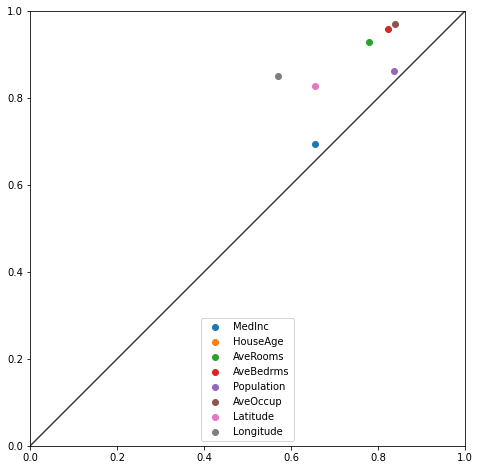

In [8]:
single_feature_imbalances = pd.DataFrame(
    [get_performance_pair(df, feature, target) for feature in tqdm.tqdm(features)],
    index=features, 
    columns=["feat_to_target", "target_to_feat"]
).astype(float)

fig, ax = plt.subplots(figsize=(8, 8))

for feature in features:
    point = single_feature_imbalances.loc[feature]
    ax.scatter(point.min(), point.max(), label=feature)
ax.legend()

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(loc="lower center")
draw_diagonal(ax)

single_feature_imbalances

In [9]:
best_feature = single_feature_imbalances.sum(axis=1).idxmin()
best_feature

'MedInc'

In [20]:
pre_selected = [best_feature]
non_selected = list(set(features) - set(pre_selected))

second_feature_imbalances = pd.DataFrame(
    {feature: get_performance_pair(df, feature, target, pre_selected=pre_selected) for feature in tqdm.tqdm(non_selected)}
).T

second_feature_imbalances

  0%|          | 0/7 [00:00<?, ?it/s]

,feat_to_target,target_to_feat
Population,0.858284,0.865824
AveOccup,0.630376,0.650854
Latitude,0.643314,0.704506
AveRooms,0.694318,0.665608
HouseAge,0.693764,0.860450
Longitude,0.622748,0.725062
AveBedrms,0.690924,0.614156


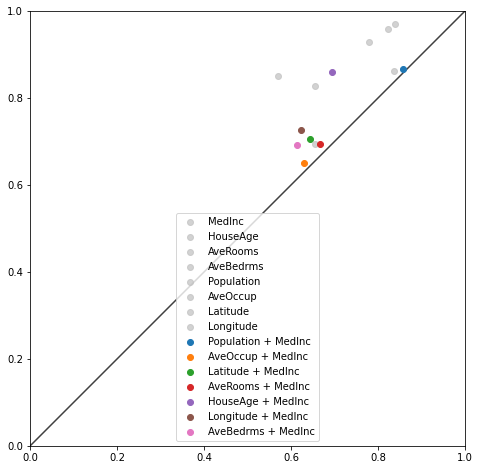

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))

for feature in features:
    point = single_feature_imbalances.loc[feature]
    ax.scatter(point.min(), point.max(), label=feature, color="silver", alpha=0.7)

for feature in non_selected:
    point = second_feature_imbalances.loc[feature]
    ax.scatter(point.min(), point.max(), label=feature + " + " + " + ".join(pre_selected))
ax.legend()

ax.set_xlim(-0.0, 1.0)
ax.set_ylim(-0.0, 1.0)
ax.legend(loc="lower center")
draw_diagonal(ax)

In [22]:
second_best_feature = second_feature_imbalances.sum(axis=1).idxmin()
second_best_feature

'AveOccup'

In [23]:
pre_selected = [best_feature, second_best_feature]
non_selected = list(set(features) - set(pre_selected))

third_feature_imbalances = pd.DataFrame(
    {feature: get_performance_pair(df, feature, target, pre_selected=pre_selected) for feature in tqdm.tqdm(non_selected)}
).T

third_feature_imbalances

  0%|          | 0/6 [00:00<?, ?it/s]

,feat_to_target,target_to_feat
Population,0.864004,0.861976
Latitude,0.584692,0.710018
AveRooms,0.621856,0.646670
HouseAge,0.651836,0.836512
Longitude,0.552990,0.723580
AveBedrms,0.642070,0.621586


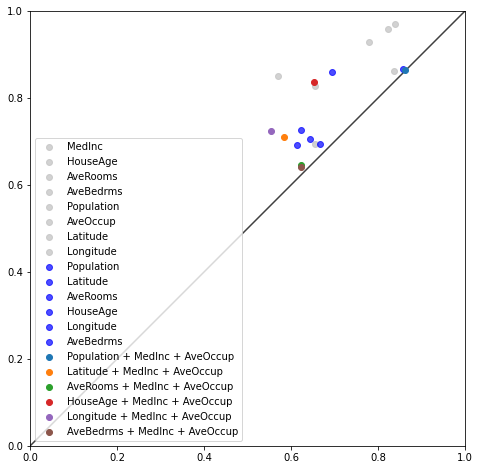

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

for feature in features:
    point = single_feature_imbalances.loc[feature]
    ax.scatter(point.min(), point.max(), label=feature, color="silver", alpha=0.7)

for feature in non_selected:
    point = second_feature_imbalances.loc[feature]
    ax.scatter(point.min(), point.max(), label=feature, color="blue", alpha=0.7)

for feature in non_selected:
    point = third_feature_imbalances.loc[feature]
    ax.scatter(point.min(), point.max(), label=feature + " + " + " + ".join(pre_selected))    

ax.legend()

ax.set_xlim(-0.0, 1.0)
ax.set_ylim(-0.0, 1.0)
ax.legend(loc="lower left")
draw_diagonal(ax)

In [27]:
third_best_feature = third_feature_imbalances.sum(axis=1).idxmin()

third_best_feature

'AveBedrms'

In [28]:
information_imbalance(df[features].values, df[[target]].values)

0.934996

In [29]:
information_imbalance(df[[target]].values, df[features].values)

0.865244